# Perceptron Algorithm: Intuitive Explanation and Implementation

This notebook provides a clear explanation of the perceptron algorithm, a foundational linear classifier, and demonstrates its implementation in Python with improved variable names and code clarity.

## What is the Perceptron?

The perceptron is a simple yet powerful linear classification algorithm. It attempts to find a hyperplane that separates data points into two classes. The perceptron updates its weights based on misclassifications, gradually improving its ability to distinguish between the two classes.

The perceptron makes predictions using the following rule:

```python
prediction = sign(bias + w1 * x1 + w2 * x2 + ... + wn * xn)
```

The weights are updated as follows:

```python
weight_i = weight_i + learning_rate * (target - prediction) * feature_i
```

Let's implement the perceptron algorithm in Python with clear variable names and explanations.

In [28]:
# Import necessary libraries
import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.01, num_epochs=100):
        """
        Initialize the perceptron classifier.
        Args:
            learning_rate (float): Step size for weight updates.
            num_epochs (int): Number of passes over the training dataset.
        """
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs

    def fit(self, features, labels):
        """
        Train the perceptron on the provided data.
        Args:
            features (ndarray): Training vectors, shape = [n_samples, n_features]
            labels (ndarray): Target values, shape = [n_samples]
        """
        self.weights = np.zeros(features.shape[1])
        self.bias = 0.0
        self.errors_per_epoch = []

        for _ in range(self.num_epochs):
            errors = 0
            for x_i, target in zip(features, labels):
                prediction = self.predict(x_i)
                update = self.learning_rate * (target - prediction)
                self.weights += update * x_i
                self.bias += update
                errors += int(update != 0.0)
            self.errors_per_epoch.append(errors)
        return self

    def net_input(self, features):
        """
        Calculate the linear combination of weights and input features.
        """
        return np.dot(features, self.weights) + self.bias

    def predict(self, features):
        """
        Return class label after unit step.
        """
        return np.where(self.net_input(features) >= 0.0, 1, -1)


In [29]:
# Create a simple dataset
X_train = np.array([[2.0, 1.0], [3.0, 4.0], [4.0, 2.0], [3.0, 1.0]])
y_train = np.array([-1, 1, 1, -1])

# Initialize and train the perceptron
perceptron = Perceptron(learning_rate=0.01, num_epochs=100)
perceptron.fit(X_train, y_train)

# Predict on new samples
X_test = np.array([[5.0, 2.0], [1.0, 3.0]])
predictions = perceptron.predict(X_test)
print("Predictions for new samples:", predictions)

Predictions for new samples: [-1  1]


In [30]:
import numpy as np

class PerceptronVectorized:
    def __init__(self, learning_rate=0.01, num_epochs=100):
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs

    def fit(self, X, y):
        """
        Vectorized training of the perceptron.
        X: shape (n_samples, n_features)
        y: shape (n_samples,)
        """
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.errors_per_epoch = []

        for _ in range(self.num_epochs):
            # Compute predictions for all samples
            linear_output = np.dot(X, self.weights) + self.bias
            predictions = np.where(linear_output >= 0.0, 1, -1)
            
            # Compute updates for misclassified samples
            errors = y - predictions  # +2, -2, or 0
            update_mask = errors != 0
            
            # Vectorized weight and bias update
            self.weights += self.learning_rate * np.dot(errors, X)
            self.bias += self.learning_rate * errors.sum()
            
            # Count number of misclassified samples
            self.errors_per_epoch.append(update_mask.sum())

        return self

    def net_input(self, X):
        return np.dot(X, self.weights) + self.bias

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)


### Perceptron Class: Methods Explained

- **`__init__`**: Sets the learning rate and number of training epochs.
- **`fit`**: Trains the perceptron by iteratively updating weights and bias for each misclassified sample.
- **`net_input`**: Computes the weighted sum of inputs plus bias.
- **`predict`**: Applies the sign function to the net input to produce a class label (+1 or -1).

Let's see how to use this class with a simple dataset.

In [31]:
# Create a simple dataset
X_train = np.array([[2.0, 1.0], [3.0, 4.0], [4.0, 2.0], [3.0, 1.0]])
y_train = np.array([-1, 1, 1, -1])

# Initialize and train the perceptron
perceptron = PerceptronVectorized(learning_rate=0.01, num_epochs=100)
perceptron.fit(X_train, y_train)

# Predict on new samples
X_test = np.array([[5.0, 2.0], [1.0, 3.0]])
predictions = perceptron.predict(X_test)
print("Predictions for new samples:", predictions)

Predictions for new samples: [1 1]


In [32]:
#### Visualizing Training Progress

#The perceptron tracks the number of misclassifications in each epoch. Let's plot this to see how the algorithm learns over time.

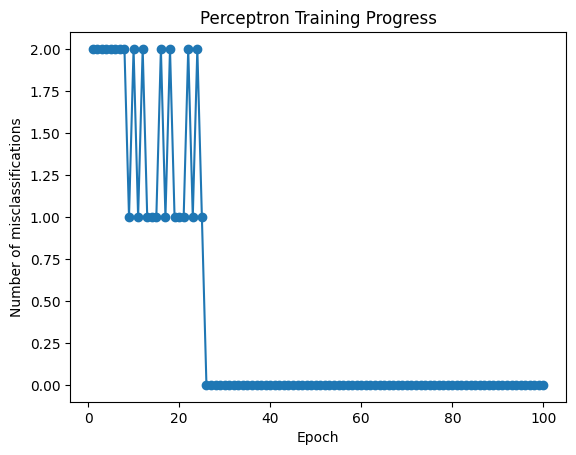

In [33]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(perceptron.errors_per_epoch) + 1), perceptron.errors_per_epoch, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Number of misclassifications')
plt.title('Perceptron Training Progress')
plt.show()